In [152]:
import numpy as np
import laspy
import pandas as pd
import os
import open3d as o3d
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull, QhullError


In [153]:
# 1. Variables to modify
excel_saint_bruno_path = "/Users/loiccv/Documents/UQAM/RStudio_1st_project/Markdown/Donnees2025_St-Bruno.xlsx"
bloc_number = 6
month = "mai"
year = 2026
# bloc_file_path = f'/Users/loiccv/Documents/UQAM/BlocsSaintBruno/Mai_{year}/Ready For Segmentation/Bloc{bloc_number}_offground_points.laz' # for 2024
# bloc_file_path = f'/Users/loiccv/Documents/UQAM/BlocsSaintBruno/Mai_{year}/Ready_for_seg/Bloc{bloc_number}_ready_seg.laz' # for 2025
bloc_file_path = f"/Users/loiccv/Documents/UQAM/2026/2026_blocs_cleaned/2026_bloc{bloc_number}_processedCC.las"

output_dir = f"{month}_{year}_segmentation_bloc{bloc_number}_for_html_report"
os.makedirs(output_dir, exist_ok=True)

In [154]:
# 2. Load naming conventions from excel
data = pd.read_excel(excel_saint_bruno_path)

tree_dict = dict(zip(data['New ID'], data['Espèce']))
bloc_dict = data.groupby('Bloc')['New ID'].apply(list).to_dict()

tree_ids = bloc_dict.get(bloc_number, [])
# print(f"Tree IDs for Bloc {bloc_number}: {tree_ids}")

In [155]:
# 3. Load and Downsample Point Cloud for Initial Segmentation
las = laspy.read(bloc_file_path)
print("Number of points in the original LAS file:", len(las.x))
points_full = np.column_stack((las.x, las.y, las.z))
# points_full = np.column_stack((las.X, las.Y, las.Z))

# Heavily downsample the point cloud for a fast initial clustering
step = 20
points = np.column_stack((las.x[::step], las.y[::step], las.z[::step]))
downsample_ratio = len(points) / len(points_full)
print("Number of points in the downsampled point cloud:", len(points), "with step size:", step)
PC = o3d.geometry.PointCloud()
PC.points = o3d.utility.Vector3dVector(points)

# o3d.visualization.draw_geometries([PC])

Number of points in the original LAS file: 7907001
Number of points in the downsampled point cloud: 395351 with step size: 20


In [156]:
# 4. Visualize point cloud with clustering
clustering = DBSCAN(
        eps=0.2, 
        min_samples=10,
        # algorithm='kd_tree',  # Use KD-tree for spatial indexing
        # leaf_size=100,  # Larger leaf_size reduces memory but slightly decreases performance
        n_jobs=-1  # Use all CPU cores
    ).fit(points)
labels = clustering.labels_ # 0 to max_label for valid clusters, -1 for noise points

max_label = labels.max()
print(f"Number of clusters: {max_label + 1}")

colors = np.random.uniform(0, 1, (max_label + 1, 3))
point_colors = colors[labels]
PC.colors = o3d.utility.Vector3dVector(point_colors)
# o3d.visualization.draw_geometries([PC])

Number of clusters: 229


In [157]:
# 5. Filter clusters based on size
size_threshold = 4650 * downsample_ratio # I found this manually, it may need adjustment based on the dataset
# size_threshold = 4650 * downsample_ratio # I found this manually, it may need adjustment based on the dataset
# size_threshold = 300*20*2*4/step # I found this manually, it may need adjustment based on the dataset

# Count points in each cluster
unique_labels, counts = np.unique(labels[labels >= 0], return_counts=True)
cluster_sizes = dict(zip(unique_labels, counts))

# Create mask for points to keep (large clusters only)
keep_mask = np.zeros(len(labels), dtype=bool)
for i, label in enumerate(labels):
    if label >= 0 and cluster_sizes.get(label, 0) >= size_threshold:
        keep_mask[i] = True

filtered_points = points[keep_mask]
filtered_labels = labels[keep_mask]

PC_filtered = o3d.geometry.PointCloud()
PC_filtered.points = o3d.utility.Vector3dVector(filtered_points)

max_label = filtered_labels.max()
colors = np.random.uniform(0, 1, (max_label + 1, 3))
point_colors = colors[filtered_labels]
PC_filtered.colors = o3d.utility.Vector3dVector(point_colors)

unique_clusters = np.unique(filtered_labels[filtered_labels >= 0])
print(f"Number of filtered clusters: {len(unique_clusters)}")
if len(unique_clusters) != 30:
    print(f"Warning: Expected 30 clusters (individual trees), but found {len(unique_clusters)}")
    o3d.visualization.draw_geometries([PC_filtered])


# o3d.visualization.draw_geometries([PC_filtered])

Number of filtered clusters: 30


In [158]:
# 6. Get bounding box coordinates for each cluster to determine spatial ordering
cluster_centers = {} 
for cluster_id in unique_clusters:
    cluster_mask = filtered_labels == cluster_id
    cluster_points = filtered_points[cluster_mask]
    
    # Positionnement du centre du cluster
    center_x = np.median(cluster_points[:, 0])
    center_y = np.median(cluster_points[:, 1])
    cluster_centers[cluster_id] = (center_x, center_y)

column_width = 5.0
sorted_clusters = sorted(
    cluster_centers.items(), 
    key=lambda item: (
        round(item[1][0] / column_width),  # Primary sort: Group by column
        item[1][1]                       # Secondary sort: Top-to-bottom within the column
    )
)     

Algorithm automatically detected 2 natural columns and sorted them.


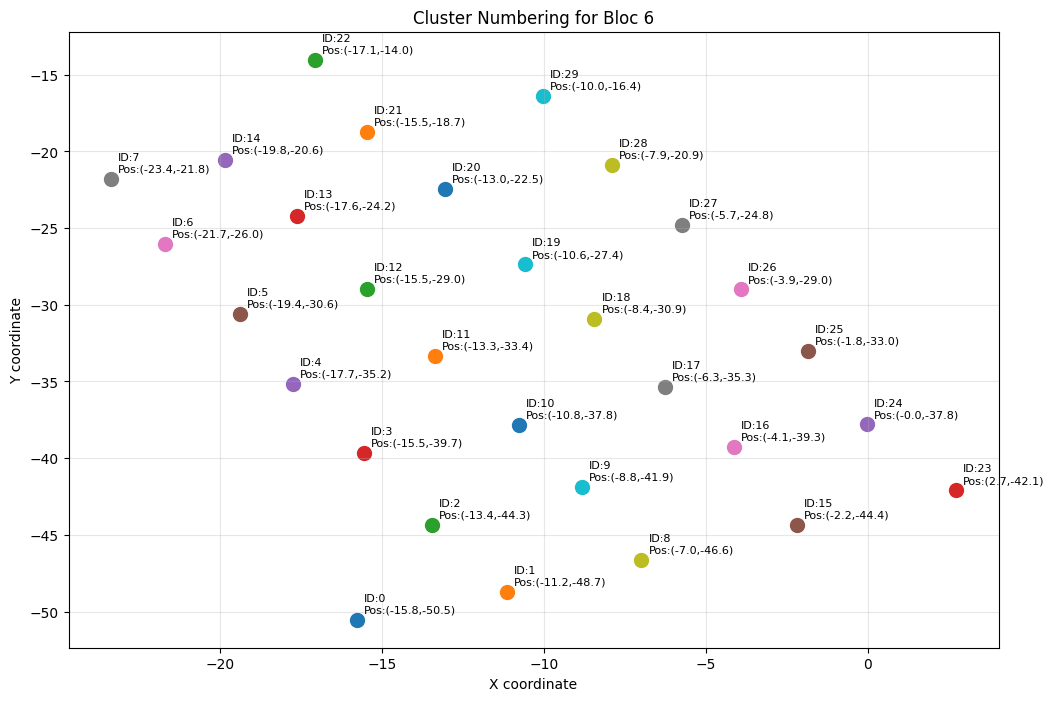

In [159]:
# 7. Plot Ids to validate spatial ordering



import math
import statistics
import matplotlib.pyplot as plt

def swap_id(id1, id2):
    sorted_clusters[id1], sorted_clusters[id2] = (
        sorted_clusters[id2],
        sorted_clusters[id1],
    )


# ---------------------------------------------------------
# THE GEOMETRIC PROJECTION AUTOPILOT (V5)
# ---------------------------------------------------------

n = len(sorted_clusters)
min_y = min(item[1][1] for item in sorted_clusters)

# --- STEP 1: Find the true structural angle ---
angles = []
for i in range(n):
    x1, y1 = sorted_clusters[i][1]
    best_dist = float('inf')
    best_angle = None
    
    for j in range(n):
        if i == j: continue
        x2, y2 = sorted_clusters[j][1]
        
        dy = y2 - y1
        dx = x2 - x1
        
        # Filter out flat cross-row jumps
        if dy > 0 and dy > abs(dx) * 0.2: 
            # Squash Y to prioritize vertical structural neighbors (Restored from V3)
            dist = math.hypot(dx, dy * 0.2)
            if dist < best_dist:
                best_dist = dist
                best_angle = math.atan2(dx, dy)
                
    if best_angle is not None:
        angles.append(best_angle)

dominant_angle = statistics.median(angles) if angles else 0.0

# --- STEP 2: Project all trees to the baseline ---
projected_points = []
for item in sorted_clusters:
    idx, (x, y) = item
    # This mathematical trick "straightens" slants by calculating exactly 
    # where the tree's root would hit the baseline.
    proj_x = x - (y - min_y) * math.tan(dominant_angle)
    projected_points.append((proj_x, item))

# --- STEP 3: Sort Left-to-Right by projected base ---
projected_points.sort(key=lambda p: p[0])

# --- STEP 4: Group into columns using 1D clustering ---
columns = []
current_col = []
GAP_THRESHOLD = 2.5  # If the X gap between trees is > 2.5, it's a new row.

for i, (proj_x, item) in enumerate(projected_points):
    if not current_col:
        current_col.append(item)
    else:
        # Check distance from the previous tree's projected base
        last_proj_x = projected_points[i-1][0]
        if proj_x - last_proj_x > GAP_THRESHOLD:
            columns.append(current_col)
            current_col = [item]
        else:
            current_col.append(item)
            
if current_col:
    columns.append(current_col)

# --- STEP 5: Sort internally Bottom-to-Top ---
for col in columns:
    col.sort(key=lambda item: item[1][1])

# --- STEP 6: Flatten and assign final order ---
final_sorted_clusters = []
for col in columns:
    final_sorted_clusters.extend(col)

sorted_clusters = final_sorted_clusters

swap_id(2, 4)
swap_id(3, 6)
swap_id(11, 4)
swap_id(15, 5)
swap_id(19, 6)
swap_id(23, 7)
swap_id(8, 11)
swap_id(15, 9)
swap_id(11, 10)
swap_id(11, 12)
swap_id(13, 17)
swap_id(14, 21)
swap_id(12, 13)
swap_id(13, 14)
swap_id(15, 25)
swap_id(14, 15)
swap_id(15, 19)
swap_id(16, 23)
swap_id(17, 19)
swap_id(18, 21)
swap_id(19, 21)
swap_id(20, 22)
swap_id(21, 26)
swap_id(22, 28)
swap_id(23, 29)
swap_id(25, 24)
swap_id(25, 26)
swap_id(26, 29)
swap_id(27, 28)
swap_id(29, 28)


print(f"Algorithm automatically detected {len(columns)} natural columns and sorted them.")

# ---------------------------------------------------------
# PLOT TO VALIDATE
# ---------------------------------------------------------
plt.figure(figsize=(12, 8)) 
for i, (cluster_id, (x, y)) in enumerate(sorted_clusters):
    plt.scatter(x, y, s=100)
    plt.annotate(f'ID:{i}\nPos:({x:.1f},{y:.1f})', (x, y), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

try:
    plt.title(f'Cluster Numbering for Bloc {bloc_number}')
except NameError:
    plt.title('Cluster Numbering (Geometric Projection V5)')

plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.grid(True, alpha=0.3)
plt.show()

In [160]:
# This simply uses a 3d cube bounding box to get points from the full-res point cloud. It is fast but may include points from little patches on the ground or neighboring trees.
def get_original_points(coarse_cluster_points, id, bbox_expansion=0.5):
    min_bound = np.min(coarse_cluster_points, axis=0)
    max_bound = np.max(coarse_cluster_points, axis=0)
    
    extent = max_bound - min_bound
    expanded_min_bound = min_bound - extent * bbox_expansion
    expanded_max_bound = max_bound + extent * bbox_expansion
    # 3. Extract points from the *full-resolution* point cloud within the expanded BBox
    mask_full_res = (
        (points_full[:, 0] >= expanded_min_bound[0]) & (points_full[:, 0] <= expanded_max_bound[0]) &
        (points_full[:, 1] >= expanded_min_bound[1]) & (points_full[:, 1] <= expanded_max_bound[1]) &
        (points_full[:, 2] >= expanded_min_bound[2]) & (points_full[:, 2] <= expanded_max_bound[2])
    )
    roi_points_full = points_full[mask_full_res]
    if len(roi_points_full) < 1000:
        print(f"Warning: Too few points ({len(roi_points_full)}) found in BBox for cluster {id}. This is probably not a tree, skipping.")
        return None
    return roi_points_full


def get_original_points_hull(coarse_cluster_points, id, bbox_expansion=0.1, chunk_size=50000):
    hull = ConvexHull(coarse_cluster_points)
    
    if bbox_expansion != 0:
        centroid = np.mean(coarse_cluster_points, axis=0)
        expanded_points = centroid + (coarse_cluster_points - centroid) * (1 + bbox_expansion)
        hull = ConvexHull(expanded_points)
    
    A = hull.equations[:, :-1]
    b = hull.equations[:, -1]
    
    mask_full_res = np.zeros(len(points_full), dtype=bool)
    
    for i in range(0, len(points_full), chunk_size):
        end_idx = min(i + chunk_size, len(points_full))
        chunk = points_full[i:end_idx]
        mask_full_res[i:end_idx] = np.all((A @ chunk.T + b[:, np.newaxis]) <= 0, axis=0)
    
    roi_points_full = points_full[mask_full_res]
    
    if len(roi_points_full) < 1000:
        print(f"Warning: Too few points ({len(roi_points_full)}) found in hull for cluster {id}. Skipping.")
        return None
    
    return roi_points_full

def get_original_points_hull_layer(coarse_cluster_points, id, layer_thickness=0.1):
    from scipy.spatial import ConvexHull
    
    z_min = coarse_cluster_points[:, 2].min()
    z_max = coarse_cluster_points[:, 2].max()
    
    num_layers = int(np.ceil((z_max - z_min) / layer_thickness)) + 1
    layer_bounds = []
    
    for i in range(num_layers):
        z_lower = z_min + i * layer_thickness
        z_upper = z_lower + layer_thickness
        
        layer_mask = (coarse_cluster_points[:, 2] >= z_lower) & (coarse_cluster_points[:, 2] < z_upper)
        layer_points = coarse_cluster_points[layer_mask]
        
        if len(layer_points) < 3:
            continue
        
        try:
            hull_2d = ConvexHull(layer_points[:, :2])
            layer_bounds.append((z_lower, z_upper, hull_2d))
        except:
            continue
    
    mask_full_res = np.zeros(len(points_full), dtype=bool)
    
    for z_lower, z_upper, hull_2d in layer_bounds:
        z_mask = (points_full[:, 2] >= z_lower) & (points_full[:, 2] < z_upper)
        candidate_points = points_full[z_mask, :2]
        
        if len(candidate_points) == 0:
            continue
        
        A = hull_2d.equations[:, :-1]
        b = hull_2d.equations[:, -1]
        inside = np.all((A @ candidate_points.T + b[:, np.newaxis]) <= 0, axis=0)
        
        z_indices = np.where(z_mask)[0]
        mask_full_res[z_indices[inside]] = True
    
    roi_points_full = points_full[mask_full_res]
    
    if len(roi_points_full) < 1000:
        print(f"Warning: Too few points ({len(roi_points_full)}) found for cluster {id}. Skipping.")
        return None
    
    return roi_points_full


# This helps clean up noise and points from neighboring trees.
def individual_tree_clustering(points, id):
    dbscan_fine = DBSCAN(eps=0.3, min_samples=10, #algorithm='kd_tree',  # Use KD-tree for spatial indexing
        # leaf_size=1000000,  # Larger leaf_size reduces memory but slightly decreases performance
        n_jobs=-1  # Use all CPU cores
    ).fit(points)
    labels_fine = dbscan_fine.labels_

    # Find the largest cluster, which should be the tree, and discard noise (-1).
    unique_labels, counts = np.unique(labels_fine[labels_fine >= 0], return_counts=True)
    if len(counts) == 0:
        print(f"Warning: No clusters found in refined DBSCAN for tree {id}. Using all points in BBox.")
        final_tree_points = points
    else:
        largest_cluster_label = unique_labels[np.argmax(counts)]
        final_tree_points = points[labels_fine == largest_cluster_label]
        return final_tree_points


def clean_tree_floor(points):
    start_height_m = 0.4
    slice_thickness_m = 0.001
    floor_height_m = 0.2
    scale_factor = 0.1 # Add a small margin to the bounding box (10%)
    max_trunk_diameter_m = 0.50  # Maximum trunk diameter of 50cm (to account for tutor) 

    points_copy = points.copy()
    min_z = np.min(points_copy[:, 2])
    points_copy[:, 2] -= min_z

    hull_properties = []
    for z in np.arange(start_height_m, floor_height_m, -slice_thickness_m):
        slice_mask = (points_copy[:, 2] >= z) & (points_copy[:, 2] < z + slice_thickness_m)
        slice_points_2d = points_copy[slice_mask, :2]
        
        if slice_points_2d.shape[0] >= 3:
            # Get centroid of all points in slice
            centroid = np.mean(slice_points_2d, axis=0)
            
            # Filter points based on max diameter constraint
            distances = np.linalg.norm(slice_points_2d - centroid, axis=1)
            valid_points = slice_points_2d[distances <= max_trunk_diameter_m/2]
            
            if len(valid_points) >= 3:
                try:
                    hull = ConvexHull(valid_points)
                    hull_vertices = valid_points[hull.vertices]
                    center = np.mean(hull_vertices, axis=0)
                    extent = np.max(hull_vertices, axis=0) - np.min(hull_vertices, axis=0)
                    hull_properties.append({'center': center, 'extent': extent})
                except QhullError:
                    print(f"Error computing convex hull for the id of the tree below")
                    continue

    if not hull_properties:
        print("No valid hull properties found. Returning original points.")
        return points

    avg_center = np.mean([p['center'] for p in hull_properties], axis=0)
    avg_extent = np.mean([p['extent'] for p in hull_properties], axis=0)
    scaled_half_extent = (avg_extent / 2) * (1 + scale_factor)
    filter_min_xy = avg_center - scaled_half_extent
    filter_max_xy = avg_center + scaled_half_extent

    floor_mask = points_copy[:, 2] < floor_height_m
    points_above_floor = points_copy[~floor_mask]
    floor_points = points_copy[floor_mask]

    keep_mask = (
        (floor_points[:, 0] >= filter_min_xy[0]) & (floor_points[:, 0] <= filter_max_xy[0]) &
        (floor_points[:, 1] >= filter_min_xy[1]) & (floor_points[:, 1] <= filter_max_xy[1])
    )
    kept_floor_points = floor_points[keep_mask]
    
    cleaned_points_normalized = np.vstack((points_above_floor, kept_floor_points))
    cleaned_points_normalized[:, 2] += min_z
    return cleaned_points_normalized

def clean_tree(points):
    k = 10
    m = 3.0

    #  Convert NumPy array to Open3D point cloud
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)

    # 3 Successive SOR filters applied with Karl's parameters
    pcd_clean1, _ = pcd.remove_statistical_outlier(nb_neighbors=k, std_ratio=m)
    pcd_clean2, _ = pcd_clean1.remove_statistical_outlier(nb_neighbors=k, std_ratio=m)
    pcd_clean3, _ = pcd_clean2.remove_statistical_outlier(nb_neighbors=k, std_ratio=m)
    clean_points = np.asarray(pcd_clean3.points)
    return clean_points

def export_tree(id, points, output_dir):
    header = laspy.LasHeader(point_format=3, version="1.2")
    # header.offsets = np.min(points, axis=0)
    # header.scales = np.array([0.0001, 0.0001, 0.0001])  # precise at 0.1 mm
    header.offsets = las.header.offset 
    header.scales = las.header.scale

    las_out = laspy.LasData(header)
    las_out.x = points[:, 0]
    las_out.y = points[:, 1]
    las_out.z = points[:, 2]

    tree_id = int(tree_ids[id])
    tree_species = tree_dict.get(tree_id, "Unknown")
    filename = f"{tree_id}_{tree_species}_bloc{bloc_number}_{month}_{year}.laz"
    filepath = os.path.join(output_dir, filename)
    las_out.write(filepath)
    print(f"Exported {filename} with {len(points)} points.")

In [161]:
print(f"Refining and exporting {len(sorted_clusters)} trees to {output_dir}/\\n")

for i, (cluster_id, (center_x, center_y)) in enumerate(sorted_clusters):
    # 1. Get the coarse cluster points
    coarse_cluster_mask = filtered_labels == cluster_id
    coarse_cluster_points = filtered_points[coarse_cluster_mask]

    # 1. Isolate the individual tree points using DBSCAN on the full-resolution points
    tree_points = individual_tree_clustering(coarse_cluster_points, i)

    # 2. Get the original points from the full-resolution point cloud within the expanded bounding box of the tree
    tree_points = get_original_points_hull(tree_points, i)

    # 3. Clean the floor points of the isolated tree
    before_cleaning_ground_count = len(tree_points)
    tree_points = clean_tree_floor(tree_points)
    cleaned_count = before_cleaning_ground_count - len(tree_points)
    print(f"Tree {i}: {cleaned_count} points removed from floor cleaning")

    # 4. Apply 3 SOR filters before exporting
    before_SOR_cleaning_count = len(tree_points)
    tree_points = clean_tree(tree_points)
    cleaned_count = before_SOR_cleaning_count - len(tree_points)
    print(f"Tree {i}: {cleaned_count} points removed by the type of successive SOR filtering inspired by Karl")

    # 5. Export the cleaned tree points
    export_tree(i, tree_points, output_dir)

print(f"\\nFinished exporting {len(sorted_clusters)} full-resolution trees to {output_dir}/")

Refining and exporting 30 trees to mai_2026_segmentation_bloc6_for_html_report/\n
Tree 0: 325 points removed from floor cleaning
Tree 0: 170 points removed by the type of successive SOR filtering inspired by Karl
Exported 601_GLTR_bloc6_mai_2026.laz with 7059 points.
Tree 1: 163 points removed from floor cleaning
Tree 1: 513 points removed by the type of successive SOR filtering inspired by Karl
Exported 602_QUMA_bloc6_mai_2026.laz with 12885 points.
Error computing convex hull for the id of the tree below
Tree 2: 619 points removed from floor cleaning
Tree 2: 1513 points removed by the type of successive SOR filtering inspired by Karl
Exported 603_ACSA_bloc6_mai_2026.laz with 63526 points.
Error computing convex hull for the id of the tree below
Tree 3: 349 points removed from floor cleaning
Tree 3: 1461 points removed by the type of successive SOR filtering inspired by Karl
Exported 604_ULAC_bloc6_mai_2026.laz with 50510 points.
Tree 4: 543 points removed from floor cleaning
Tree 4: 

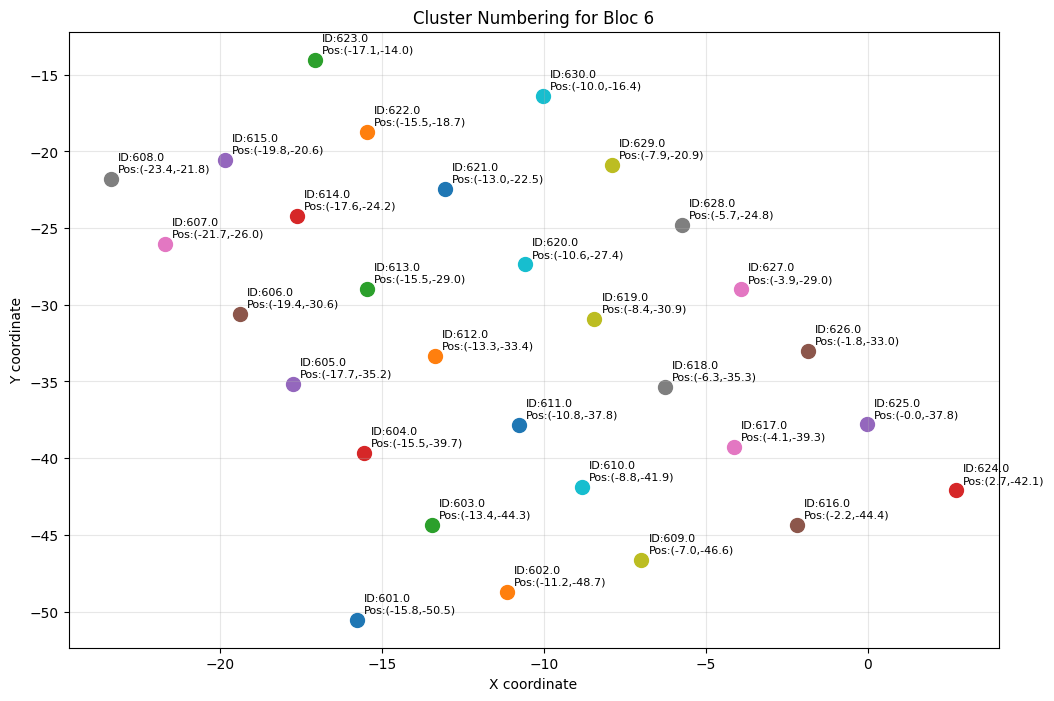

In [162]:
# 8. Plot the clusters with IDs and positions to validate spatial ordering
plt.figure(figsize=(12, 8))
for i, (cluster_id, (x, y)) in enumerate(sorted_clusters):
    plt.scatter(x, y, s=100)
    plt.annotate(f'ID:{tree_ids[i]}\nPos:({x:.1f},{y:.1f})', (x, y), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.title(f'Cluster Numbering for Bloc {bloc_number}')
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.grid(True, alpha=0.3)
plt.show()